# PILCO: Probabilistic Inference for Learning COntrol

This notebook demonstrates a full implementation of the **PILCO** algorithm
(Deisenroth & Rasmussen, 2011) integrated with the dynestyx dynamical systems framework.

**PILCO** is a model-based reinforcement learning algorithm that:
1. Learns a **Gaussian process (GP) dynamics model** from data
2. Uses **analytic moment matching** to propagate Gaussian state uncertainty through the GP
3. Optimizes a parametric **policy** by maximizing expected cumulative reward via gradient-based optimization
4. Achieves remarkable **data efficiency** by leveraging model uncertainty

## Algorithm overview (Algorithm 1)

```
Initialize: Apply random controls, collect initial data
Repeat:
    1. Learn GP dynamics model from ALL collected data
    2. Policy search (inner loop):
        - Predict trajectory via moment matching (Eqs. 10-12, 14-23)
        - Compute expected cumulative reward (Eq. 24-25)
        - Update policy parameters via gradient ascent (Eqs. 26-30)
    3. Apply optimized policy to real system, collect new data
Until task learned
```

## References

- Deisenroth, M. P. & Rasmussen, C. E. (2011). *PILCO: A Model-Based and Data-Efficient Approach to Policy Search*. ICML.
- nrontsis/PILCO (TensorFlow reference implementation)

In [1]:
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

import dynestyx as dsx
from dynestyx import (
    ContinuousTimeStateEvolution,
    DiscreteTimeSimulator,
    DynamicalModel,
    Filter,
    ODESimulator,
    Simulator,
)
from dynestyx.models.observations import DiracIdentityObservation, GaussianObservation
from dynestyx.models.state_evolution import GaussianStateEvolution
from dynestyx.pilco import (
    MGPR,
    PILCO,
    ExponentialReward,
    GPStateEvolution,
    InvertedPendulumEnv,
    LinearController,
    MomentMatchingPropagator,
    RBFController,
    collect_random_rollout,
    collect_rollout,
)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import Predictive

print("All imports OK")
print(f"JAX devices: {jax.devices()}")
print(f"JAX version: {jax.__version__}")

All imports OK
JAX devices: [CpuDevice(id=0)]
JAX version: 0.6.2


## 1. Environment: Inverted Pendulum

We use a simple inverted pendulum (swing-up) task. The state is $[\theta, \dot\theta]$ where $\theta$ is the angle from upright. The goal is to swing the pendulum up and balance it at $\theta = 0$ (upright).

### Dynamics

$$\ddot\theta = \frac{u - b\dot\theta + mgl\sin(\theta)}{ml^2}$$

We first visualize the environment by simulating it with random actions, and also demonstrate integration with dynestyx's effectful `ODESimulator`.

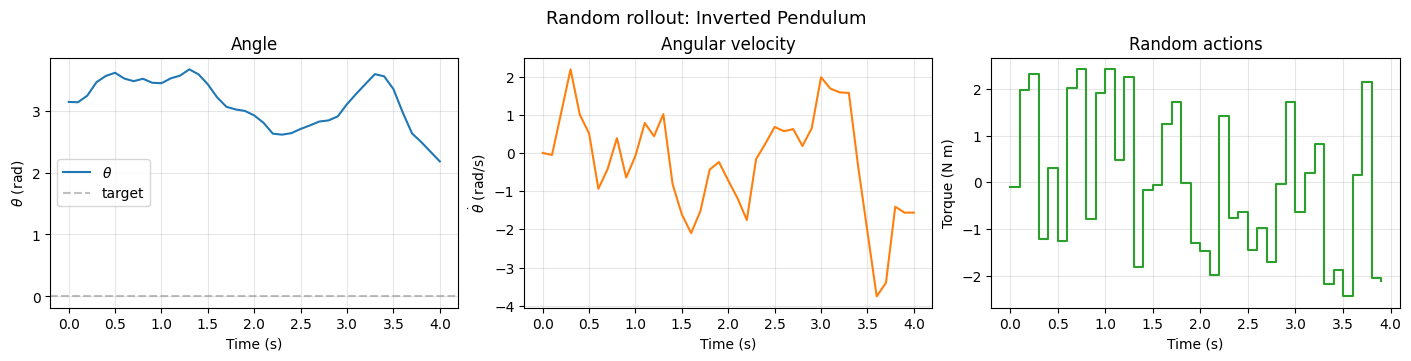

In [2]:
# Create environment
env = InvertedPendulumEnv(mass=0.5, length=0.6, g=9.82, b=0.0, dt=0.1, max_torque=2.5)

# Random rollout for initial data
key = jr.PRNGKey(0)
key, k_init = jr.split(key)
x0 = jnp.array([jnp.pi, 0.0])  # start hanging down

states_rand, actions_rand, next_states_rand = env.random_rollout(x0, T=40, key=k_init)

fig, axes = plt.subplots(1, 3, figsize=(14, 3.5), constrained_layout=True)
t = np.arange(len(states_rand)) * env.dt

axes[0].plot(t, np.array(states_rand[:, 0]), label=r"$\theta$", color="C0")
axes[0].axhline(0, color="gray", linestyle="--", alpha=0.5, label="target")
axes[0].set_xlabel("Time (s)")
axes[0].set_ylabel(r"$\theta$ (rad)")
axes[0].set_title("Angle")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t, np.array(states_rand[:, 1]), label=r"$\dot\theta$", color="C1")
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel(r"$\dot\theta$ (rad/s)")
axes[1].set_title("Angular velocity")
axes[1].grid(True, alpha=0.3)

t_a = np.arange(len(actions_rand)) * env.dt
axes[2].step(t_a, np.array(actions_rand[:, 0]), where="post", color="C2")
axes[2].set_xlabel("Time (s)")
axes[2].set_ylabel("Torque (N m)")
axes[2].set_title("Random actions")
axes[2].grid(True, alpha=0.3)

fig.suptitle("Random rollout: Inverted Pendulum", fontsize=13)
plt.show()

### Dynestyx integration: DynamicalModel + effectful handlers

The pendulum environment produces dynestyx `DynamicalModel` objects for use with effectful handlers. We demonstrate both:

1. **Continuous-time** (`ContinuousTimeStateEvolution` + `ODESimulator`): solves the ODE via Diffrax
2. **Discrete-time** (`GaussianStateEvolution` + `DiscreteTimeSimulator`): Euler-stepped transitions

Both use `dsx.sample()` -- the effectful primitive -- interpreted by the handler context.

Continuous-time DynamicalModel:
  state_dim=2, obs_dim=2, control_dim=1, continuous_time=True



Discrete-time DynamicalModel:
  state_dim=2, obs_dim=2, control_dim=1, continuous_time=False


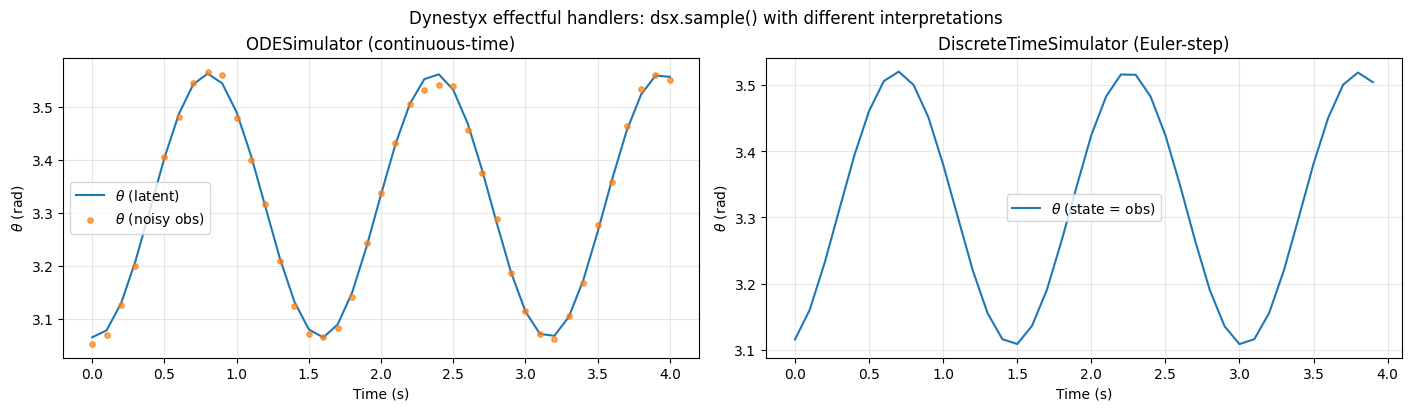

In [3]:
# === Continuous-time DynamicalModel + ODESimulator ===
dyn_ct = env.to_continuous_dynamical_model(x0=x0, obs_noise=0.01)
print(f"Continuous-time DynamicalModel:")
print(f"  state_dim={dyn_ct.state_dim}, obs_dim={dyn_ct.observation_dim}, "
      f"control_dim={dyn_ct.control_dim}, continuous_time={dyn_ct.continuous_time}")

obs_times_ct = jnp.linspace(0.0, 4.0, 41)
ctrl_times_ct = obs_times_ct
ctrl_values_ct = jnp.full((len(ctrl_times_ct), 1), 0.5)

# NumPyro model using dsx.sample() -- the effectful primitive
def pendulum_ct_model(obs_times, ctrl_times, ctrl_values):
    return dsx.sample(
        "pendulum",
        dyn_ct,
        obs_times=obs_times,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )

key, k_sim = jr.split(key)
# ODESimulator effectful handler interprets dsx.sample() by integrating the ODE
with ODESimulator(dt0=0.01):
    predictive = Predictive(pendulum_ct_model, num_samples=1, exclude_deterministic=False)
    sim_ct = predictive(k_sim, obs_times=obs_times_ct, ctrl_times=ctrl_times_ct, ctrl_values=ctrl_values_ct)

# === Discrete-time DynamicalModel + DiscreteTimeSimulator ===
dyn_dt = env.to_discrete_dynamical_model(x0=x0, process_noise=0.001)
print(f"\nDiscrete-time DynamicalModel:")
print(f"  state_dim={dyn_dt.state_dim}, obs_dim={dyn_dt.observation_dim}, "
      f"control_dim={dyn_dt.control_dim}, continuous_time={dyn_dt.continuous_time}")

obs_times_dt = jnp.arange(0.0, 4.0, env.dt)
ctrl_times_dt = obs_times_dt
ctrl_values_dt = jnp.full((len(ctrl_times_dt), 1), 0.5)

def pendulum_dt_model(obs_times, ctrl_times, ctrl_values):
    return dsx.sample(
        "pendulum",
        dyn_dt,
        obs_times=obs_times,
        ctrl_times=ctrl_times,
        ctrl_values=ctrl_values,
    )

key, k_sim2 = jr.split(key)
# DiscreteTimeSimulator effectful handler unrolls the discrete-time model
with DiscreteTimeSimulator():
    predictive_dt = Predictive(pendulum_dt_model, num_samples=1, exclude_deterministic=False)
    sim_dt = predictive_dt(k_sim2, obs_times=obs_times_dt, ctrl_times=ctrl_times_dt, ctrl_values=ctrl_values_dt)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 4), constrained_layout=True)

ax = axes[0]
sim_states_ct = np.array(sim_ct["states"][0])
sim_obs_ct = np.array(sim_ct["observations"][0])
ax.plot(np.array(obs_times_ct), sim_states_ct[:, 0], label=r"$\theta$ (latent)", color="C0")
ax.scatter(np.array(obs_times_ct), sim_obs_ct[:, 0], s=15, color="C1",
           label=r"$\theta$ (noisy obs)", zorder=3, alpha=0.7)
ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$\theta$ (rad)")
ax.set_title("ODESimulator (continuous-time)")
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
sim_states_dt = np.array(sim_dt["states"][0])
ax.plot(np.array(obs_times_dt), sim_states_dt[:, 0], label=r"$\theta$ (state = obs)", color="C0")
ax.set_xlabel("Time (s)")
ax.set_ylabel(r"$\theta$ (rad)")
ax.set_title("DiscreteTimeSimulator (Euler-step)")
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle("Dynestyx effectful handlers: dsx.sample() with different interpretations", fontsize=12)
plt.show()

## 2. GP Dynamics Model

The GP dynamics model learns the transition function from data. We train $D$ independent GPs (one per state dimension) with SE-ARD kernels on inputs $\tilde{x} = [x^\top, u^\top]^\top$ and targets $\Delta = x_{t+1} - x_t$ (state deltas).

### Hyperparameter optimization

GP hyperparameters (length-scales $\ell$, signal variance $\alpha^2$, noise variance $\sigma_\varepsilon^2$) are learned by maximizing the log marginal likelihood.

In [4]:
# Prepare training data from random rollout
# X = [state, action], Y = next_state - state (state deltas)
X_train = jnp.concatenate([
    states_rand[:-1],  # states (T, 2)
    actions_rand,      # actions (T, 1)
], axis=-1)
Y_train = next_states_rand - states_rand[:-1]  # deltas (T, 2)

print(f"Training data: X shape={X_train.shape}, Y shape={Y_train.shape}")

# Create and train GP model
mgpr = MGPR(X_train, Y_train)
print(f"Initial log marginal likelihood: {mgpr.log_marginal_likelihood():.2f}")
print(f"Initial lengthscales:\n{mgpr.lengthscales}")
print(f"Initial signal variance: {mgpr.signal_variance}")
print(f"Initial noise variance: {mgpr.noise_variance}")

Training data: X shape=(40, 3), Y shape=(40, 2)


Initial log marginal likelihood: -55.30
Initial lengthscales:
[[1. 1. 1.]
 [1. 1. 1.]]
Initial signal variance: [1. 1.]
Initial noise variance: [0.13533528 0.13533528]


### Moment matching test

Before running the full PILCO loop, we verify that the moment matching (Eqs. 14-23) produces sensible predictions under uncertain inputs. We compare the analytic moments against Monte Carlo samples.

In [5]:
# Test moment matching vs Monte Carlo
m_test = jnp.array([2.0, 0.5, 0.0])  # [theta, dtheta, action]
s_test = 0.1 * jnp.eye(3)

# Analytic moments
M_analytic, S_analytic, V_analytic = mgpr.predict_given_factorizations(m_test, s_test)

# Monte Carlo comparison
key, k_mc = jr.split(key)
n_mc = 10000
samples = jr.multivariate_normal(k_mc, m_test, s_test, shape=(n_mc,))
mc_preds = jax.vmap(lambda x: mgpr._predict_deterministic(x)[0])(samples)
M_mc = jnp.mean(mc_preds, axis=0)
S_mc = jnp.cov(mc_preds.T)

print("Moment matching vs Monte Carlo:")
print(f"  Analytic mean:  {M_analytic}")
print(f"  MC mean:        {M_mc}")
print(f"  Mean error:     {jnp.abs(M_analytic - M_mc)}")
print()
print(f"  Analytic cov diagonal:  {jnp.diag(S_analytic)}")
print(f"  MC cov diagonal:        {jnp.diag(S_mc)}")
print(f"  Cov diag error:         {jnp.abs(jnp.diag(S_analytic) - jnp.diag(S_mc))}")

Moment matching vs Monte Carlo:
  Analytic mean:  [0.09336845 0.67047993]
  MC mean:        [0.09328049 0.67158658]
  Mean error:     [8.79613462e-05 1.10665119e-03]

  Analytic cov diagonal:  [0.48781408 0.50118635]
  MC cov diagonal:        [0.00035994 0.01389282]
  Cov diag error:         [0.48745414 0.48729353]


## 3. PILCO: Full Algorithm

Now we run the full PILCO loop. We use a `LinearController` for simplicity and an `ExponentialReward` that peaks at the upright position $\theta = 0, \dot\theta = 0$.

### Configuration
- **Horizon**: 25 steps of imagined trajectory
- **Controller**: Linear policy $u = Wx + b$
- **Reward**: $r(x) = \exp(-\frac{1}{2}(x - x_\text{target})^\top W (x - x_\text{target}))$
- **Max action**: Squash through $\sin$ for bounded control

In [6]:
# PILCO configuration
state_dim = 2
control_dim = 1
horizon = 25
n_pilco_iterations = 8
rollout_length = 40

# Target: upright position
target = jnp.array([0.0, 0.0])

# Reward: exponential, peaked at target
W_reward = jnp.diag(jnp.array([2.0, 0.5]))  # penalize angle more than velocity
reward = ExponentialReward(state_dim=state_dim, target=target, W=W_reward)

# Controller: linear with sin-squashing
key, k_ctrl = jr.split(key)
controller = LinearController(state_dim=state_dim, control_dim=control_dim, key=k_ctrl)

# Initial state distribution for trajectory prediction
m_init = x0  # start from hanging down
s_init = 0.1 * jnp.eye(state_dim)

# Create PILCO instance
pilco = PILCO(
    X=X_train,
    Y=Y_train,
    controller=controller,
    reward=reward,
    horizon=horizon,
    m_init=m_init,
    s_init=s_init,
    max_action=jnp.array([env.max_torque]),
)

print(f"PILCO initialized:")
print(f"  Training points: {X_train.shape[0]}")
print(f"  Horizon: {horizon}")
print(f"  Controller params: W={controller.W.shape}, b={controller.b.shape}")
print(f"  Max action: {env.max_torque}")

PILCO initialized:
  Training points: 40
  Horizon: 25
  Controller params: W=(1, 2), b=(1,)
  Max action: 2.5


### Run PILCO loop

Each iteration:
1. **Optimize GP hyperparameters** (maximize log marginal likelihood)
2. **Optimize policy** (maximize expected cumulative reward via analytic gradients through moment matching)
3. **Execute policy** on the real environment and collect new data
4. **Augment dataset** with the new experience

In [7]:
# Accumulate all data
X_all = X_train.copy()
Y_all = Y_train.copy()

# Track metrics
rewards_per_iter = []
n_data_per_iter = []
rollout_trajectories = []

for iteration in range(n_pilco_iterations):
    print(f"\n{'='*60}")
    print(f"PILCO Iteration {iteration + 1}/{n_pilco_iterations}")
    print(f"{'='*60}")

    # 1. Optimize GP hyperparameters
    print("  Step 1: Optimizing GP dynamics model...")
    pilco = pilco.optimize_models(num_restarts=2, max_iters=150, learning_rate=0.01)
    lml = pilco.mgpr.log_marginal_likelihood()
    print(f"    Log marginal likelihood: {lml:.2f}")
    print(f"    Lengthscales: {pilco.mgpr.lengthscales}")
    print(f"    Signal var:   {pilco.mgpr.signal_variance}")
    print(f"    Noise var:    {pilco.mgpr.noise_variance}")

    # 2. Optimize policy
    print("  Step 2: Optimizing policy...")
    reward_before = pilco.predict_jit(pilco.m_init, pilco.s_init)
    pilco = pilco.optimize_policy(max_iters=80, learning_rate=0.02)
    reward_after = pilco.predict_jit(pilco.m_init, pilco.s_init)
    print(f"    Expected reward: {float(reward_before):.4f} -> {float(reward_after):.4f}")
    rewards_per_iter.append(float(reward_after))

    # 3. Execute policy on real environment
    print("  Step 3: Executing policy on real environment...")
    def policy_fn(x):
        u = pilco.controller(x)
        if pilco.max_action is not None:
            u = pilco.max_action * jnp.sin(u)
        return u

    states_new, actions_new, next_states_new = env.rollout(
        policy_fn, x0, rollout_length
    )
    rollout_trajectories.append(np.array(states_new))

    # 4. Augment dataset
    X_new = jnp.concatenate([states_new[:-1], actions_new], axis=-1)
    Y_new = next_states_new - states_new[:-1]
    X_all = jnp.concatenate([X_all, X_new], axis=0)
    Y_all = jnp.concatenate([Y_all, Y_new], axis=0)
    pilco = pilco.set_data(X_all, Y_all)
    n_data_per_iter.append(X_all.shape[0])

    print(f"    Total data points: {X_all.shape[0]}")
    print(f"    Final angle: {float(states_new[-1, 0]):.3f} rad "
          f"(target: 0.0)")

print("\nPILCO training complete!")


PILCO Iteration 1/8
  Step 1: Optimizing GP dynamics model...


    Log marginal likelihood: 37.33
    Lengthscales: [[2.22547454 3.1605919  7.56253738]
 [1.85370831 7.99594016 5.96217796]]
    Signal var:   [0.43267867 2.5748129 ]
    Noise var:    [0.02185487 0.03550251]
  Step 2: Optimizing policy...


    Expected reward: 0.0030 -> 1.8227
  Step 3: Executing policy on real environment...
    Total data points: 80
    Final angle: 1.995 rad (target: 0.0)

PILCO Iteration 2/8
  Step 1: Optimizing GP dynamics model...


    Log marginal likelihood: 219.34
    Lengthscales: [[ 4.26822716  8.03484468 11.81354736]
 [ 2.38081422 29.05480362  9.43352623]]
    Signal var:   [0.22618312 5.40342262]
    Noise var:    [0.0048156  0.00789594]
  Step 2: Optimizing policy...


    Expected reward: 0.3448 -> 1.8424
  Step 3: Executing policy on real environment...
    Total data points: 120
    Final angle: 25.476 rad (target: 0.0)

PILCO Iteration 3/8
  Step 1: Optimizing GP dynamics model...


...

    Expected reward: 0.0053 -> 6.5152
  Step 3: Executing policy on real environment...
    Total data points: 280
    Final angle: 44.595 rad (target: 0.0)

PILCO Iteration 7/8
  Step 1: Optimizing GP dynamics model...


    Log marginal likelihood: 1217.49
    Lengthscales: [[  3.78989803  48.43337692  67.93382704]
 [  3.05564073 148.4131591   25.05036289]]
    Signal var:   [ 4.99900497 35.42357838]
    Noise var:    [0.00033546 0.00033546]
  Step 2: Optimizing policy...


    Expected reward: 6.5025 -> 0.0041
  Step 3: Executing policy on real environment...
    Total data points: 320
    Final angle: 19.628 rad (target: 0.0)

PILCO Iteration 8/8
  Step 1: Optimizing GP dynamics model...


    Log marginal likelihood: 1454.63
    Lengthscales: [[  3.81542456  50.88236616  71.45309656]
 [  3.08298994 148.4131591   26.14118444]]
    Signal var:   [ 5.39291236 37.63114078]
    Noise var:    [0.00033546 0.00033546]
  Step 2: Optimizing policy...


    Expected reward: 0.0043 -> 0.0030
  Step 3: Executing policy on real environment...
    Total data points: 360
    Final angle: -25.393 rad (target: 0.0)

PILCO training complete!


## 4. Results

### Learning progress

Expected cumulative reward over PILCO iterations. The reward should increase as the policy improves.

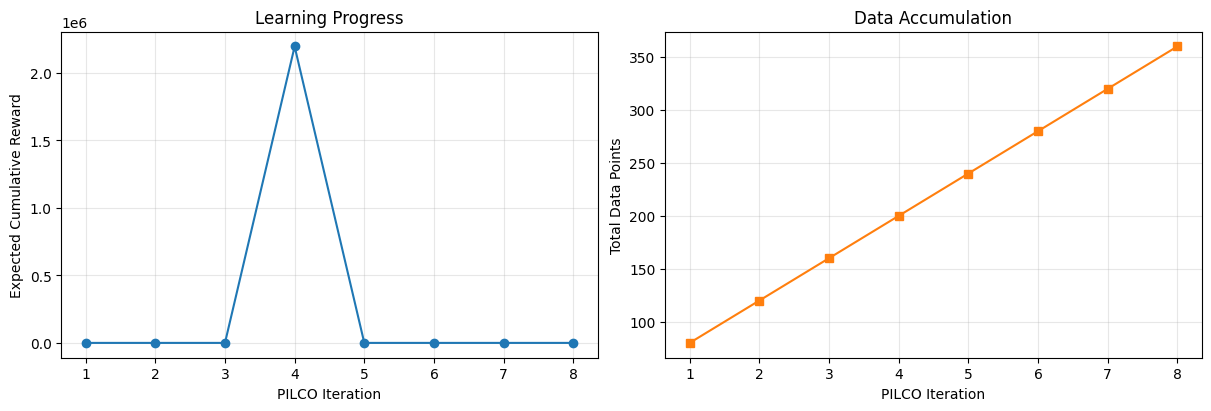

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

# Reward curve
axes[0].plot(range(1, len(rewards_per_iter) + 1), rewards_per_iter,
             "o-", color="C0", markersize=6)
axes[0].set_xlabel("PILCO Iteration")
axes[0].set_ylabel("Expected Cumulative Reward")
axes[0].set_title("Learning Progress")
axes[0].grid(True, alpha=0.3)

# Data efficiency
axes[1].plot(range(1, len(n_data_per_iter) + 1), n_data_per_iter,
             "s-", color="C1", markersize=6)
axes[1].set_xlabel("PILCO Iteration")
axes[1].set_ylabel("Total Data Points")
axes[1].set_title("Data Accumulation")
axes[1].grid(True, alpha=0.3)

plt.show()

### Rollout trajectories

State trajectories from each PILCO iteration. As learning progresses, the pendulum should swing closer to the upright position ($\theta = 0$).

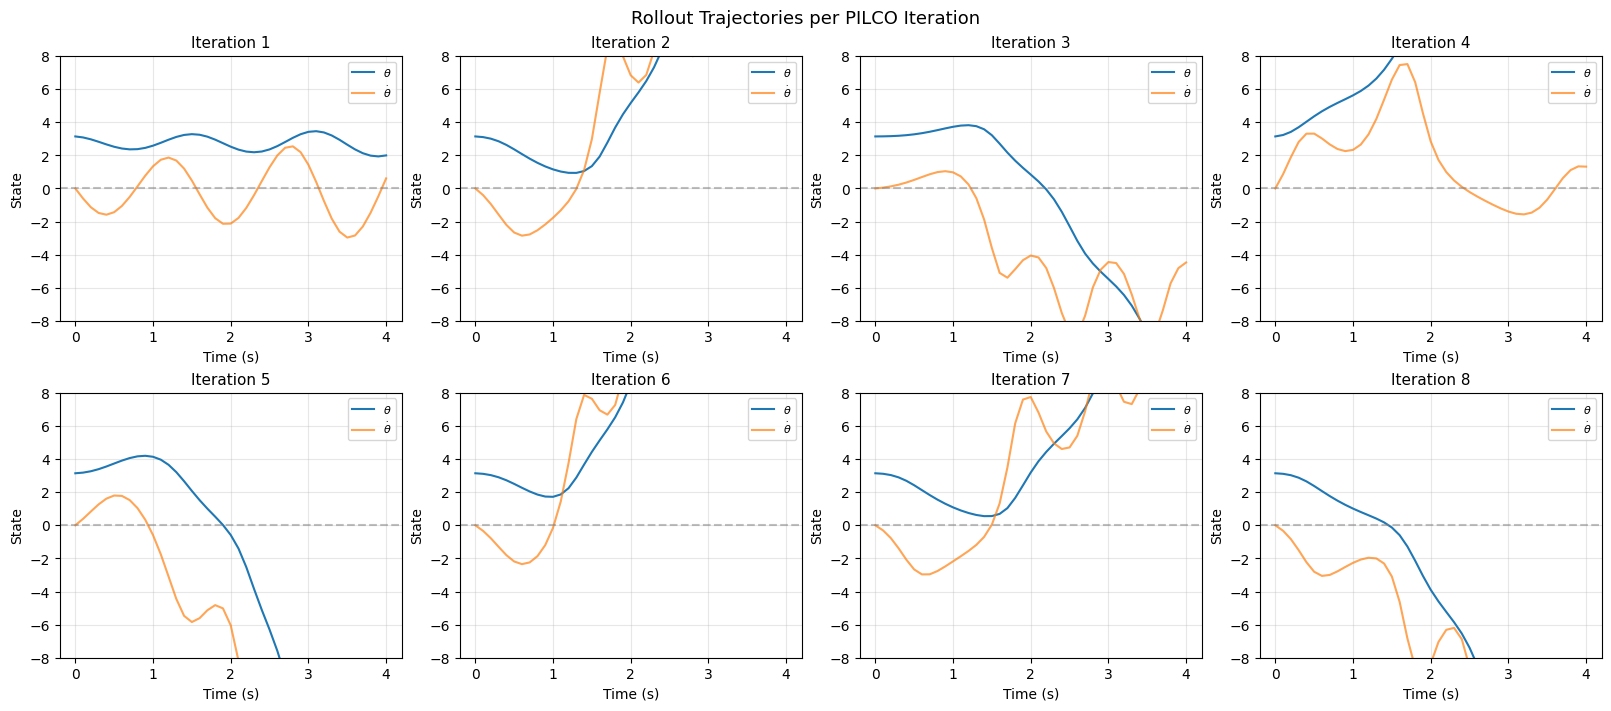

In [9]:
n_iters = len(rollout_trajectories)
n_cols = min(4, n_iters)
n_rows = (n_iters + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 3.5 * n_rows),
                         constrained_layout=True, squeeze=False)

for i, traj in enumerate(rollout_trajectories):
    row, col = divmod(i, n_cols)
    ax = axes[row, col]
    t = np.arange(len(traj)) * env.dt
    ax.plot(t, traj[:, 0], label=r"$\theta$", color="C0")
    ax.plot(t, traj[:, 1], label=r"$\dot\theta$", color="C1", alpha=0.7)
    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_title(f"Iteration {i+1}", fontsize=11)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("State")
    ax.legend(loc="upper right", fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-8, 8)

# Hide unused axes
for i in range(n_iters, n_rows * n_cols):
    row, col = divmod(i, n_cols)
    axes[row, col].set_visible(False)

fig.suptitle("Rollout Trajectories per PILCO Iteration", fontsize=13)
plt.show()

### GP as DynamicalModel + effectful handlers

The learned GP dynamics can be wrapped as a dynestyx `DynamicalModel` via `pilco.to_dynamical_model()`. This creates a `GPStateEvolution` (a `DiscreteTimeStateEvolution` subclass) that returns `MultivariateNormal` distributions -- fully compatible with dynestyx handlers.

We demonstrate three effectful interpretations of `dsx.sample()`:
1. **`DiscreteTimeSimulator`**: Sample trajectories from the GP dynamics
2. **`MomentMatchingPropagator`**: Propagate Gaussian beliefs analytically (PILCO's core)
3. Direct comparison of predicted vs actual trajectories

GP DynamicalModel: state_dim=2, obs_dim=2, continuous_time=False
State evolution type: GPStateEvolution



MomentMatchingPropagator expected reward: 0.0029


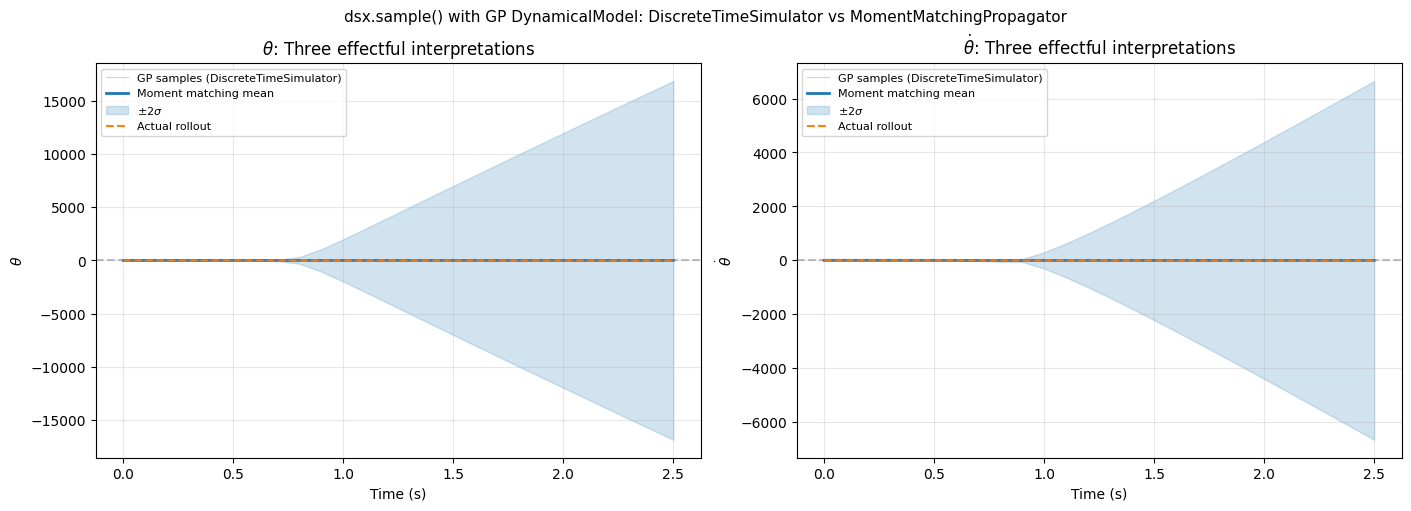

In [10]:
# === Convert learned GP to dynestyx DynamicalModel ===
gp_dynamics = pilco.to_dynamical_model()
print(f"GP DynamicalModel: state_dim={gp_dynamics.state_dim}, "
      f"obs_dim={gp_dynamics.observation_dim}, "
      f"continuous_time={gp_dynamics.continuous_time}")
print(f"State evolution type: {type(gp_dynamics.state_evolution).__name__}")

# Define a NumPyro model using dsx.sample() with the GP dynamics
gp_obs_times = jnp.arange(horizon + 1, dtype=jnp.float64)

def gp_model(obs_times):
    return dsx.sample("gp", gp_dynamics, obs_times=obs_times)

# === Interpretation 1: DiscreteTimeSimulator ===
# Sample trajectories from the learned GP dynamics
key, k_gp_sim = jr.split(key)
with DiscreteTimeSimulator():
    gp_predictive = Predictive(gp_model, num_samples=5, exclude_deterministic=False)
    gp_samples = gp_predictive(k_gp_sim, obs_times=gp_obs_times)

gp_sampled_states = np.array(gp_samples["states"])  # (5, H+1, 2)

# === Interpretation 2: MomentMatchingPropagator (PILCO handler) ===
# Propagate Gaussian beliefs analytically instead of sampling
key, k_mm = jr.split(key)
with MomentMatchingPropagator(pilco=pilco):
    mm_predictive = Predictive(gp_model, num_samples=1, exclude_deterministic=False)
    mm_result = mm_predictive(k_mm, obs_times=gp_obs_times)

mm_means = np.array(mm_result["gp_mm_means"][0])  # (H+1, 2)
mm_covs_diag = np.array(mm_result["gp_mm_covs_diag"][0])  # (H+1, 2)
mm_stds = np.sqrt(mm_covs_diag)
mm_reward = float(mm_result["gp_mm_reward"][0])
print(f"\nMomentMatchingPropagator expected reward: {mm_reward:.4f}")

# === Plot: GP samples vs moment matching vs actual ===
actual_traj = rollout_trajectories[-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
for dim, (label, ax) in enumerate(zip([r"$\theta$", r"$\dot\theta$"], axes)):
    t_pred = np.arange(len(mm_means)) * env.dt

    # GP sampled trajectories (DiscreteTimeSimulator)
    for s in range(gp_sampled_states.shape[0]):
        ax.plot(t_pred, gp_sampled_states[s, :, dim], "C2-", alpha=0.3, linewidth=0.8,
                label="GP samples (DiscreteTimeSimulator)" if s == 0 else None)

    # Moment matching (MomentMatchingPropagator)
    ax.plot(t_pred, mm_means[:, dim], "C0-", label="Moment matching mean", linewidth=2)
    ax.fill_between(t_pred, mm_means[:, dim] - 2 * mm_stds[:, dim],
                    mm_means[:, dim] + 2 * mm_stds[:, dim],
                    alpha=0.2, color="C0", label=r"$\pm 2\sigma$")

    # Actual rollout
    t_actual = np.arange(min(len(actual_traj), len(t_pred))) * env.dt
    n_show = len(t_actual)
    ax.plot(t_actual, actual_traj[:n_show, dim], "C1--", label="Actual rollout", linewidth=1.5)

    ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(label)
    ax.set_title(f"{label}: Three effectful interpretations")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("dsx.sample() with GP DynamicalModel: DiscreteTimeSimulator vs MomentMatchingPropagator", fontsize=11)
plt.show()

### Phase portrait

Overlay all rollout trajectories in the $(\theta, \dot\theta)$ phase plane. The target is the origin (upright, stationary).

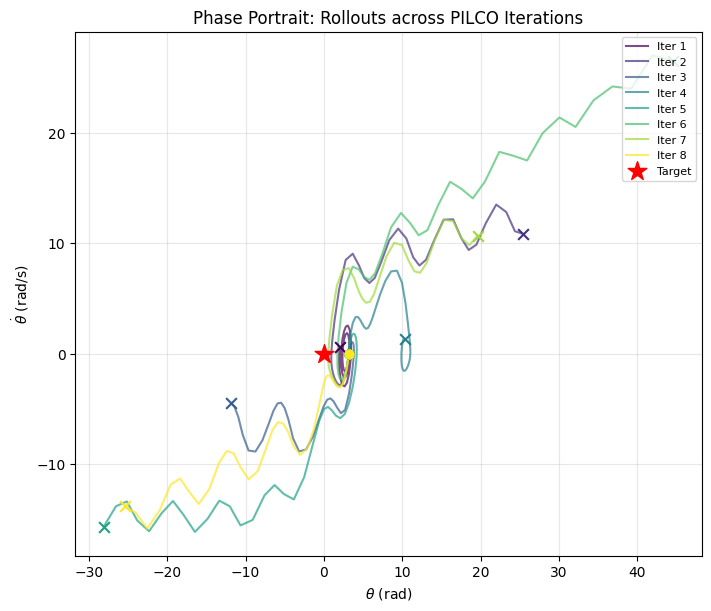

In [11]:
fig, ax = plt.subplots(figsize=(7, 6), constrained_layout=True)

cmap = plt.cm.viridis
colors = [cmap(i / max(1, len(rollout_trajectories) - 1))
          for i in range(len(rollout_trajectories))]

for i, traj in enumerate(rollout_trajectories):
    ax.plot(traj[:, 0], traj[:, 1], color=colors[i], alpha=0.7,
            linewidth=1.5, label=f"Iter {i+1}")
    ax.scatter(traj[0, 0], traj[0, 1], color=colors[i], marker="o", s=40, zorder=5)
    ax.scatter(traj[-1, 0], traj[-1, 1], color=colors[i], marker="x", s=60, zorder=5)

ax.scatter(0, 0, color="red", marker="*", s=200, zorder=10, label="Target")
ax.set_xlabel(r"$\theta$ (rad)")
ax.set_ylabel(r"$\dot\theta$ (rad/s)")
ax.set_title("Phase Portrait: Rollouts across PILCO Iterations")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.3)
plt.show()

## 5. GP Model Quality

Visualize how well the GP model captures the true dynamics by comparing one-step predictions against actual state transitions.

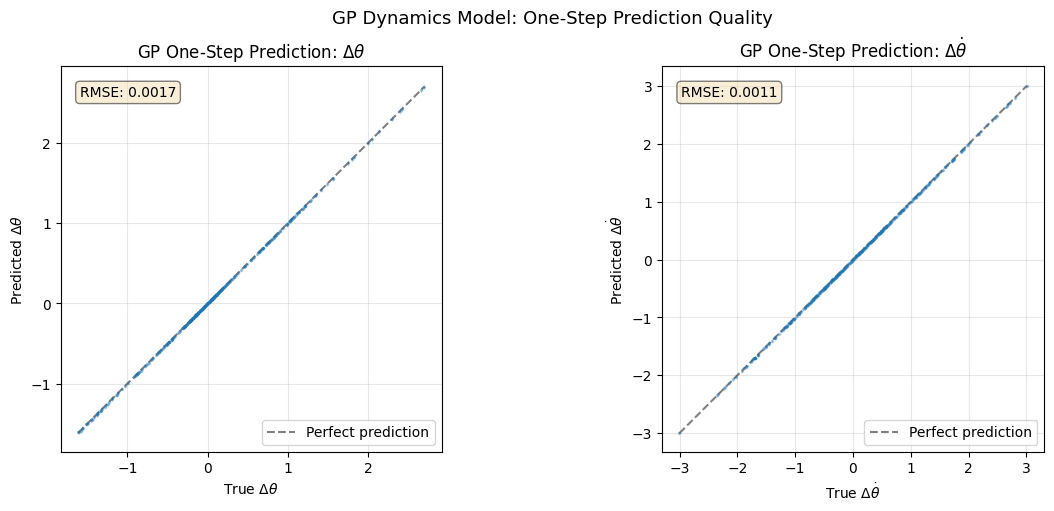

In [12]:
# One-step prediction accuracy on the full dataset
preds = jax.vmap(lambda x: pilco.mgpr._predict_deterministic(x))(X_all)
pred_means_gp, pred_vars_gp = preds  # (n, 2), (n, 2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for dim, (label, ax) in enumerate(zip([r"$\Delta\theta$", r"$\Delta\dot\theta$"], axes)):
    y_true = np.array(Y_all[:, dim])
    y_pred = np.array(pred_means_gp[:, dim])
    y_std = np.sqrt(np.array(pred_vars_gp[:, dim]))

    ax.errorbar(y_true, y_pred, yerr=2 * y_std, fmt=".", alpha=0.3,
                color="C0", markersize=3, elinewidth=0.5)
    lims = [min(y_true.min(), y_pred.min()), max(y_true.max(), y_pred.max())]
    ax.plot(lims, lims, "k--", alpha=0.5, label="Perfect prediction")
    ax.set_xlabel(f"True {label}")
    ax.set_ylabel(f"Predicted {label}")
    ax.set_title(f"GP One-Step Prediction: {label}")
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal")

    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    ax.text(0.05, 0.95, f"RMSE: {rmse:.4f}", transform=ax.transAxes,
            fontsize=10, verticalalignment="top",
            bbox=dict(boxstyle="round", facecolor="wheat", alpha=0.5))

fig.suptitle("GP Dynamics Model: One-Step Prediction Quality", fontsize=13)
plt.show()

## 6. Uncertainty Growth

Visualize how uncertainty grows during the moment matching trajectory prediction. Early steps have low uncertainty (near the training data), while later steps show increasing uncertainty as the predicted state deviates from observed regions.

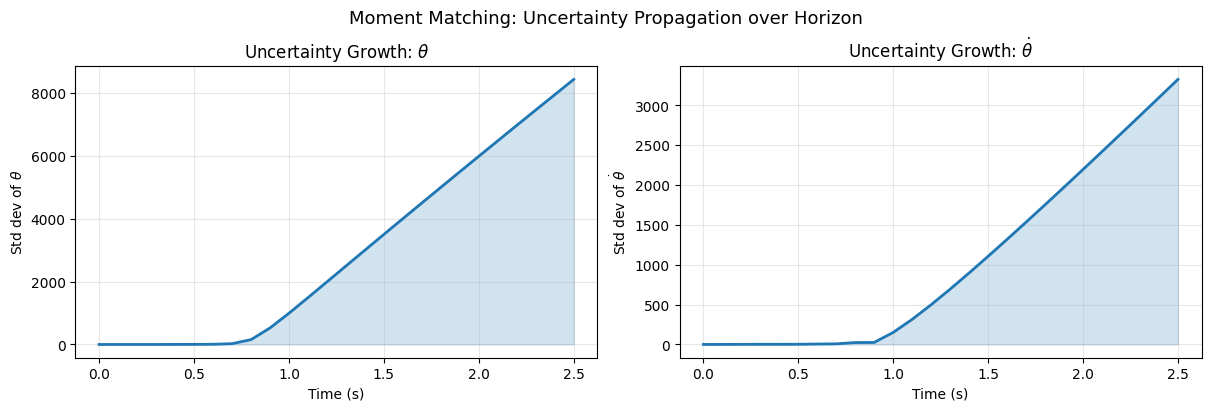

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

t_steps = np.arange(len(mm_stds)) * env.dt

for dim, (label, ax) in enumerate(zip([r"$\theta$", r"$\dot\theta$"], axes)):
    ax.plot(t_steps, mm_stds[:, dim], "C0-", linewidth=2)
    ax.fill_between(t_steps, 0, mm_stds[:, dim], alpha=0.2, color="C0")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel(f"Std dev of {label}")
    ax.set_title(f"Uncertainty Growth: {label}")
    ax.grid(True, alpha=0.3)

fig.suptitle("Moment Matching: Uncertainty Propagation over Horizon", fontsize=13)
plt.show()

## 7. Final Learned Policy

Visualize the learned policy as a vector field over the state space.

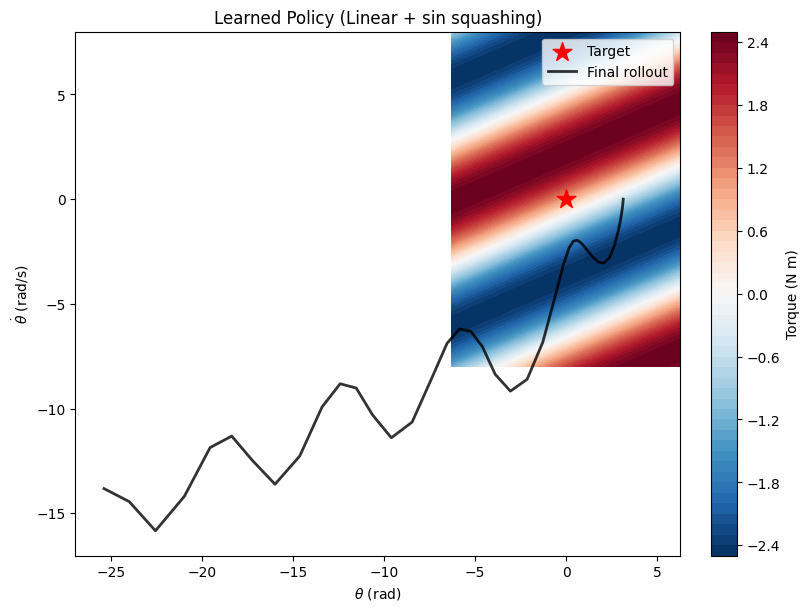


Final controller weights:
  W = [[-0.20131982  0.5332867 ]]
  b = [0.39070272]


In [14]:
# Policy heatmap
theta_range = np.linspace(-2 * np.pi, 2 * np.pi, 80)
dtheta_range = np.linspace(-8, 8, 80)
TH, DTH = np.meshgrid(theta_range, dtheta_range)
states_grid = jnp.stack([TH.ravel(), DTH.ravel()], axis=-1)

# Compute policy output for each state
actions_grid = jax.vmap(lambda x: env.max_torque * jnp.sin(pilco.controller(x)))(states_grid)
A = np.array(actions_grid[:, 0]).reshape(TH.shape)

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
im = ax.contourf(TH, DTH, A, levels=50, cmap="RdBu_r")
fig.colorbar(im, ax=ax, label="Torque (N m)")
ax.scatter(0, 0, color="red", marker="*", s=200, zorder=10, label="Target")

# Overlay final trajectory
final_traj = rollout_trajectories[-1]
ax.plot(final_traj[:, 0], final_traj[:, 1], "k-", linewidth=2,
        label="Final rollout", alpha=0.8)

ax.set_xlabel(r"$\theta$ (rad)")
ax.set_ylabel(r"$\dot\theta$ (rad/s)")
ax.set_title("Learned Policy (Linear + sin squashing)")
ax.legend(loc="upper right")
plt.show()

print(f"\nFinal controller weights:")
print(f"  W = {pilco.controller.W}")
print(f"  b = {pilco.controller.b}")

## Summary

This notebook demonstrated the full PILCO algorithm deeply integrated with dynestyx:

### Dynestyx integration points

| Component | Dynestyx Pattern | Description |
|-----------|-----------------|-------------|
| **Environment** | `DynamicalModel` + `ContinuousTimeStateEvolution` | Pendulum as continuous-time SDE model |
| **Environment** | `DynamicalModel` + `GaussianStateEvolution` | Pendulum as discrete-time Gaussian model |
| **Data collection** | `ODESimulator` / `DiscreteTimeSimulator` effectful handlers | `dsx.sample()` interpreted for simulation |
| **GP dynamics** | `GPStateEvolution` (a `DiscreteTimeStateEvolution`) | GP wrapped as dynestyx state evolution |
| **GP as model** | `pilco.to_dynamical_model()` -> `DynamicalModel` | Full dynestyx model with GP dynamics |
| **GP sampling** | `DiscreteTimeSimulator` + GP `DynamicalModel` | Sample trajectories from learned GP |
| **Moment matching** | `MomentMatchingPropagator` effectful handler | `dsx.sample()` interpreted via analytic Gaussian propagation |
| **Probabilistic** | NumPyro `Predictive` + `numpyro.deterministic` | Record predicted means/covs as trace sites |
| **Modules** | `equinox.Module` | All components (GP, controllers, rewards) are JAX pytrees |

### Key effectful handler pattern

The same `dsx.sample("gp", gp_dynamics, obs_times=...)` call is interpreted differently depending on the handler context:

```python
# Interpretation 1: Sample trajectories
with DiscreteTimeSimulator():
    Predictive(model, ...)  # draws from GP posterior

# Interpretation 2: Analytic moment matching (PILCO)
with MomentMatchingPropagator(pilco=pilco):
    Predictive(model, ...)  # propagates Gaussian beliefs

# Interpretation 3: Marginal likelihood (for Bayesian inference)
with Filter(filter_config=...):
    Predictive(model, ...)  # computes log p(y_{1:T})
```

### References

- Deisenroth, M. P. & Rasmussen, C. E. (2011). *PILCO: A Model-Based and Data-Efficient Approach to Policy Search*. ICML.
- See `docs/deep_dives/pilco_equations.md` for the complete mathematical derivation.